# Advanced Logistics Data Analytics  
## Case 14: Food Delivery Route Optimization

Model yang digunakan:
1. Decision Tree  
2. Logistic Regression  
3. k-Nearest Neighbour

## Library Setup

### 1.1  Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

### 1.2 Google Colab Upload Library

In [3]:
from google.colab import files

### 1.6 Display Settings

In [4]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

try:
    from IPython.display import display
except:
    display = print

## Data Upload and Loading

### 2.1 Upload Dataset

In [5]:
print("Please upload the CSV dataset.")
print("Example file name: Food_Delivery_Route_Efficiency_Dataset.csv")

uploaded = files.upload()

Please upload the CSV dataset.
Example file name: Food_Delivery_Route_Efficiency_Dataset.csv


Saving Food_Delivery_Route_Efficiency_Dataset.csv to Food_Delivery_Route_Efficiency_Dataset.csv


### 2.2 Read Uploaded File Name

In [6]:
file_name = list(uploaded.keys())[0]

print("Uploaded file name:", file_name)

Uploaded file name: Food_Delivery_Route_Efficiency_Dataset.csv


### 2.3 Load Dataset into DataFrame

In [9]:
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset uploaded and loaded successfully.")

Dataset uploaded and loaded successfully.


### 2.4 Preview Dataset

In [10]:
print("First five rows:")
display(data.head())

First five rows:


,order_id,distance_km,delivery_time_min,traffic_level,route_length_km,delivery_mode,weather,order_time,restaurant_zone,customer_zone
0,1,7.97,63.8,High,9.75,Bicycle,Clear,2025-01-01 15:29,South,North
1,2,0.90,7.6,High,1.28,Car,Cloudy,2025-01-03 00:47,West,North
2,3,11.12,78.0,Medium,16.65,Bike,Rainy,2025-01-04 17:32,South,Central
3,4,4.90,24.8,Low,5.25,Scooter,Rainy,2025-01-01 14:12,Central,Central
4,5,10.04,56.0,High,11.34,Car,Rainy,2025-01-02 16:50,West,North


### 2.5 Check Dataset Shape

In [11]:
print("Dataset shape:")
print(data.shape)

Dataset shape:
(200, 10)


### 2.6 Check Dataset Information

In [12]:
print("Dataset information:")
data.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           200 non-null    int64  
 1   distance_km        200 non-null    float64
 2   delivery_time_min  200 non-null    float64
 3   traffic_level      200 non-null    object 
 4   route_length_km    200 non-null    float64
 5   delivery_mode      200 non-null    object 
 6   weather            200 non-null    object 
 7   order_time         200 non-null    object 
 8   restaurant_zone    200 non-null    object 
 9   customer_zone      200 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 15.8+ KB


### 2.7 Check Missing Values

In [13]:
print("Missing values:")
display(data.isnull().sum())

Missing values:


,0
order_id,0
distance_km,0
delivery_time_min,0
traffic_level,0
route_length_km,0
delivery_mode,0
weather,0
order_time,0
restaurant_zone,0
customer_zone,0


### 2.8 Check Column Names

In [14]:
print("Column names:")
print(data.columns.tolist())

Column names:
['order_id', 'distance_km', 'delivery_time_min', 'traffic_level', 'route_length_km', 'delivery_mode', 'weather', 'order_time', 'restaurant_zone', 'customer_zone']


## Dataset Validation

### 3.1 Define Required Columns

In [15]:
required_columns = [
    "order_id",
    "distance_km",
    "delivery_time_min",
    "traffic_level",
    "route_length_km",
    "delivery_mode",
    "weather",
    "order_time",
    "restaurant_zone",
    "customer_zone"
]

### 3.2 Check Missing Required Columns

In [16]:
missing_required_columns = [col for col in required_columns if col not in data.columns]

print("Missing required columns:")
print(missing_required_columns)

Missing required columns:
[]


### 3.3 Show Dataset Validation Result

In [17]:
if len(missing_required_columns) > 0:
    print("Some required columns are missing.")
    print("Please check the CSV column names before continuing.")
else:
    print("All required columns are available. Dataset is ready for analysis.")

All required columns are available. Dataset is ready for analysis.


## Initial Data Exploration

### 4.1 Numerical Descriptive Statistics

In [18]:
print("Numerical descriptive statistics:")
display(data.describe())

Numerical descriptive statistics:


,order_id,distance_km,delivery_time_min,route_length_km
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,6.624750,44.744500,8.155850
std,57.879185,3.371918,25.083925,4.303207
min,1.000000,0.530000,2.400000,0.580000
25%,50.750000,3.687500,23.725000,4.420000
50%,100.500000,6.845000,44.650000,8.520000
75%,150.250000,9.797500,63.900000,11.800000
max,200.000000,12.000000,108.800000,17.290000


### 4.2 Define Categorical Columns to Check

In [19]:
categorical_columns_to_check = [
    "traffic_level",
    "delivery_mode",
    "weather",
    "restaurant_zone",
    "customer_zone"
]

### 4.3 Traffic Level Distribution

In [20]:
print("Traffic level distribution:")
display(data["traffic_level"].value_counts())

Traffic level distribution:


,count
traffic_level,
High,68
Medium,67
Low,65


### 4.4 Delivery Mode Distribution

In [21]:
print("Delivery mode distribution:")
display(data["delivery_mode"].value_counts())

Delivery mode distribution:


,count
delivery_mode,
Bicycle,52
Scooter,52
Bike,49
Car,47


### 4.5 Weather Distribution

In [22]:
print("Weather distribution:")
display(data["weather"].value_counts())

Weather distribution:


,count
weather,
Cloudy,55
Rainy,55
Windy,50
Clear,40


### 4.6 Restaurant Zone Distribution

In [23]:
print("Restaurant zone distribution:")
display(data["restaurant_zone"].value_counts())

Restaurant zone distribution:


,count
restaurant_zone,
South,54
Central,47
West,41
North,30
East,28


### 4.7 Customer Zone Distribution

In [24]:
print("Customer zone distribution:")
display(data["customer_zone"].value_counts())

Customer zone distribution:


,count
customer_zone,
North,46
East,45
Central,38
South,36
West,35


## Exploratory Data Visualization

### 5.1 Delivery Time Distribution

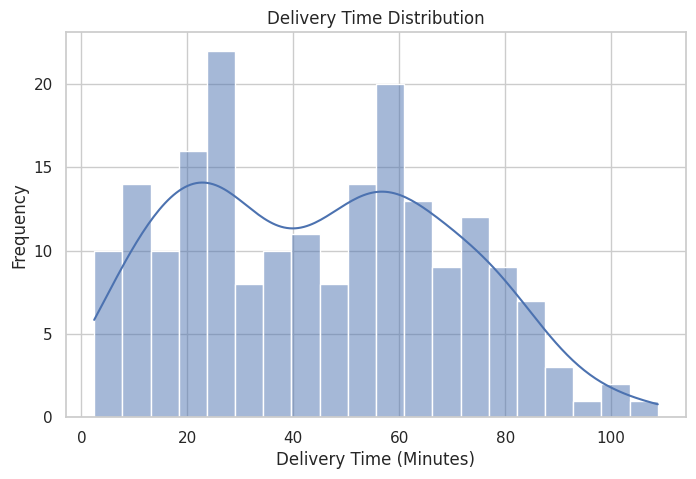

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(data["delivery_time_min"], bins=20, kde=True)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.show()

### 5.2 Delivery Time by Traffic Level

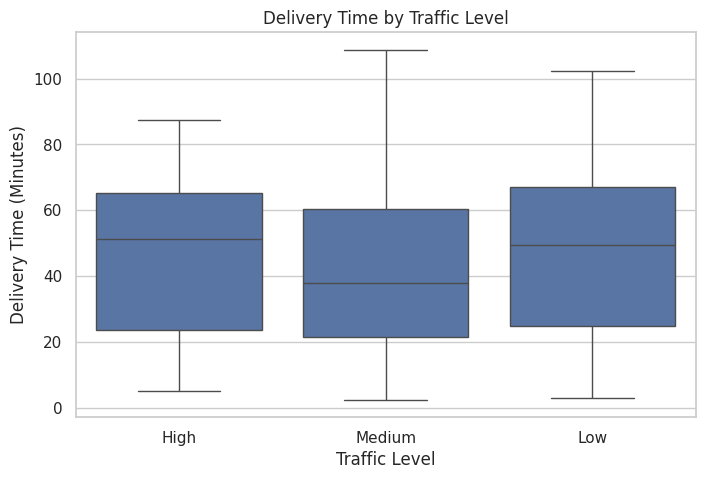

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="traffic_level", y="delivery_time_min", data=data)
plt.title("Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

### 5.3 Delivery Time by Delivery Mode

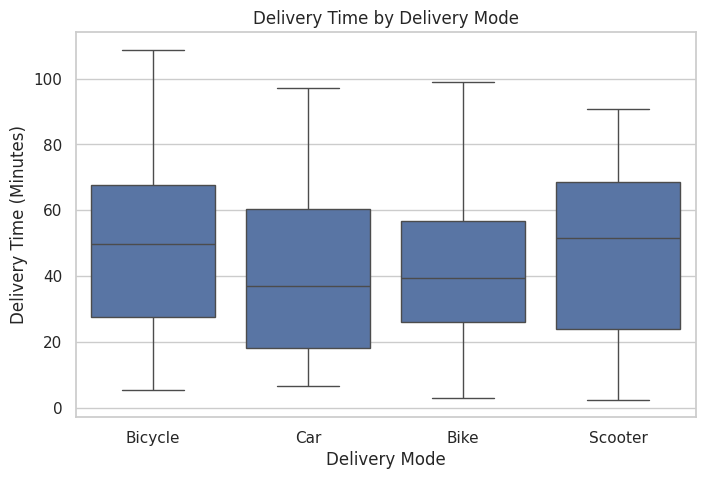

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="delivery_mode", y="delivery_time_min", data=data)
plt.title("Delivery Time by Delivery Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

### 5.4 Delivery Time by Weather Condition

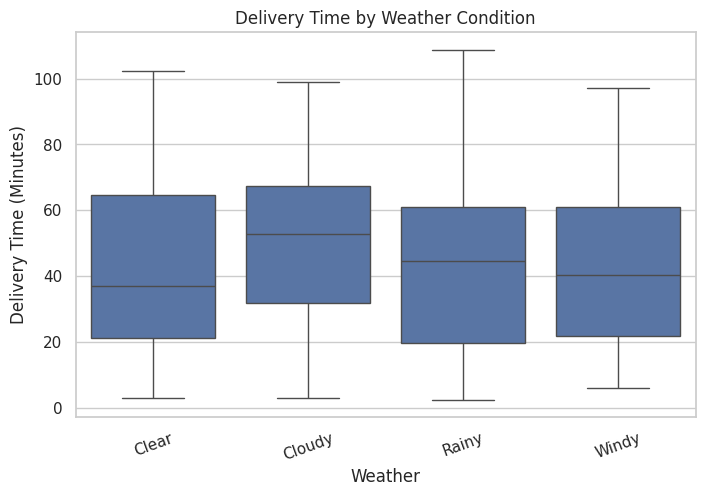

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="weather", y="delivery_time_min", data=data)
plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (Minutes)")
plt.xticks(rotation=20)
plt.show()

### 5.5 Distance and Delivery Time Relationship

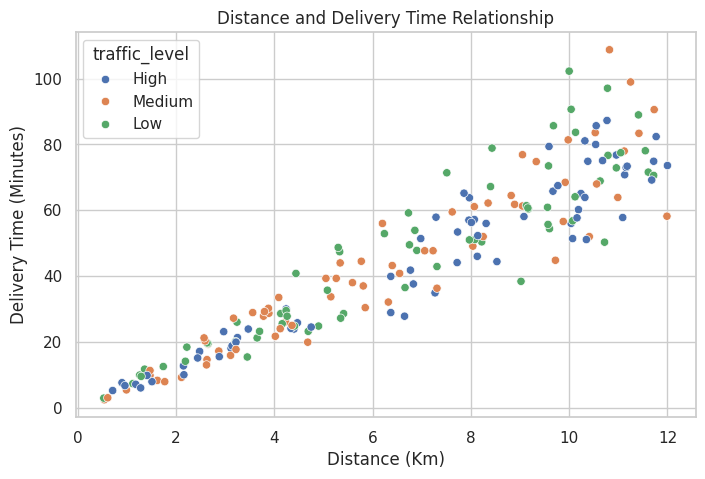

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="distance_km",
    y="delivery_time_min",
    hue="traffic_level",
    data=data
)
plt.title("Distance and Delivery Time Relationship")
plt.xlabel("Distance (Km)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

### 5.6 Define Numerical Columns for Correlation

In [30]:
numeric_cols = ["distance_km", "delivery_time_min", "route_length_km"]

print("Numerical columns for correlation:")
print(numeric_cols)

Numerical columns for correlation:
['distance_km', 'delivery_time_min', 'route_length_km']


### 5.7 Numerical Feature Correlation Heatmap

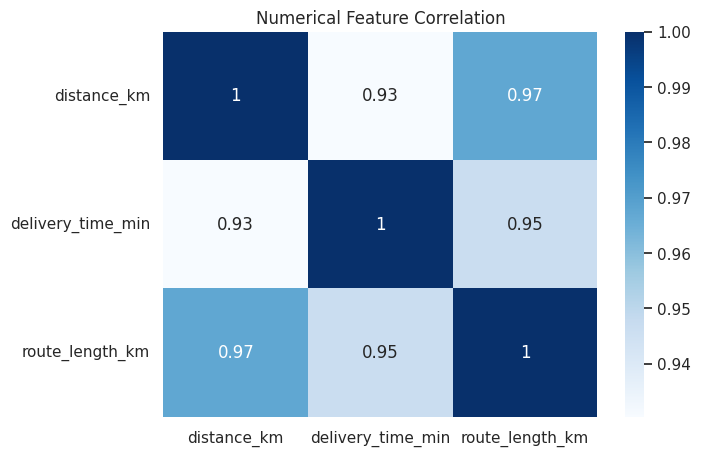

In [31]:
plt.figure(figsize=(7, 5))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Numerical Feature Correlation")
plt.show()

## Feature Engineering

### 6.1 Copy Original Dataset

In [32]:
df = data.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


### 6.2 Convert Order Time into Datetime Format

In [33]:
df["order_time"] = pd.to_datetime(df["order_time"], errors="coerce")

print("order_time converted into datetime format.")

order_time converted into datetime format.


### 6.3 Extract Order Hour

In [34]:
df["order_hour"] = df["order_time"].dt.hour

print("order_hour created successfully.")
display(df[["order_time", "order_hour"]].head())

order_hour created successfully.


,order_time,order_hour
0,2025-01-01 15:29:00,15
1,2025-01-03 00:47:00,0
2,2025-01-04 17:32:00,17
3,2025-01-01 14:12:00,14
4,2025-01-02 16:50:00,16


### 6.4 Define Time Category Function

In [35]:
def categorize_time(hour):
    if pd.isna(hour):
        return "Unknown"
    elif 5 <= hour < 11:
        return "Morning"
    elif 11 <= hour < 15:
        return "Afternoon"
    elif 15 <= hour < 19:
        return "Evening"
    else:
        return "Night"

### 6.5 Create Time Category Feature

In [36]:
df["time_category"] = df["order_hour"].apply(categorize_time)

print("time_category created successfully.")
display(df[["order_hour", "time_category"]].head())

time_category created successfully.


,order_hour,time_category
0,15,Evening
1,0,Night
2,17,Evening
3,14,Afternoon
4,16,Evening


### 6.6 Create Same Zone Feature

In [37]:
df["same_zone"] = np.where(df["restaurant_zone"] == df["customer_zone"], 1, 0)

print("same_zone created successfully.")
display(df[["restaurant_zone", "customer_zone", "same_zone"]].head())

same_zone created successfully.


,restaurant_zone,customer_zone,same_zone
0,South,North,0
1,West,North,0
2,South,Central,0
3,Central,Central,1
4,West,North,0


### 6.7 Create Time per Kilometer Feature

In [38]:
df["time_per_km"] = df["delivery_time_min"] / df["distance_km"]

print("time_per_km created successfully.")
display(df[["delivery_time_min", "distance_km", "time_per_km"]].head())

time_per_km created successfully.


,delivery_time_min,distance_km,time_per_km
0,63.8,7.97,8.005019
1,7.6,0.90,8.444444
2,78.0,11.12,7.014388
3,24.8,4.90,5.061224
4,56.0,10.04,5.577689


### 6.8 Create Route Efficiency Ratio Feature

In [39]:
df["route_efficiency_ratio"] = df["distance_km"] / df["route_length_km"]

print("route_efficiency_ratio created successfully.")
display(df[["distance_km", "route_length_km", "route_efficiency_ratio"]].head())

route_efficiency_ratio created successfully.


,distance_km,route_length_km,route_efficiency_ratio
0,7.97,9.75,0.817436
1,0.90,1.28,0.703125
2,11.12,16.65,0.667868
3,4.90,5.25,0.933333
4,10.04,11.34,0.885362


### 6.9 Handle Infinite Values

In [40]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


### 6.10 Drop Missing Values after Feature Engineering

In [41]:
df.dropna(inplace=True)

print("Missing values removed successfully.")
print("Dataset shape after cleaning:", df.shape)

Missing values removed successfully.
Dataset shape after cleaning: (200, 15)


### 6.11 Preview Engineered Dataset

In [42]:
print("Dataset after feature engineering:")
display(df.head())

Dataset after feature engineering:


,order_id,distance_km,delivery_time_min,traffic_level,route_length_km,delivery_mode,weather,order_time,restaurant_zone,customer_zone,order_hour,time_category,same_zone,time_per_km,route_efficiency_ratio
0,1,7.97,63.8,High,9.75,Bicycle,Clear,2025-01-01 15:29:00,South,North,15,Evening,0,8.005019,0.817436
1,2,0.90,7.6,High,1.28,Car,Cloudy,2025-01-03 00:47:00,West,North,0,Night,0,8.444444,0.703125
2,3,11.12,78.0,Medium,16.65,Bike,Rainy,2025-01-04 17:32:00,South,Central,17,Evening,0,7.014388,0.667868
3,4,4.90,24.8,Low,5.25,Scooter,Rainy,2025-01-01 14:12:00,Central,Central,14,Afternoon,1,5.061224,0.933333
4,5,10.04,56.0,High,11.34,Car,Rainy,2025-01-02 16:50:00,West,North,16,Evening,0,5.577689,0.885362


### 6.12 Check Columns after Feature Engineering

In [43]:
print("Columns after feature engineering:")
print(df.columns.tolist())

Columns after feature engineering:
['order_id', 'distance_km', 'delivery_time_min', 'traffic_level', 'route_length_km', 'delivery_mode', 'weather', 'order_time', 'restaurant_zone', 'customer_zone', 'order_hour', 'time_category', 'same_zone', 'time_per_km', 'route_efficiency_ratio']


## Target Construction

### 7.1 Create MinMax Scaler for Target Construction

In [44]:
scaler_target = MinMaxScaler()

print("MinMaxScaler created successfully.")

MinMaxScaler created successfully.


### 7.2 Scale Time-Based Variables

In [45]:
df[["time_per_km_scaled", "delivery_time_scaled"]] = scaler_target.fit_transform(
    df[["time_per_km", "delivery_time_min"]]
)

print("time_per_km and delivery_time_min scaled successfully.")
display(df[["time_per_km_scaled", "delivery_time_scaled"]].head())

time_per_km and delivery_time_min scaled successfully.


,time_per_km_scaled,delivery_time_scaled
0,0.632207,0.577068
1,0.704845,0.048872
2,0.468454,0.710526
3,0.145593,0.210526
4,0.230966,0.503759


### 7.3 Create Route Inefficiency Score

In [46]:
df["route_inefficiency_score"] = 1 - df["route_efficiency_ratio"]

print("route_inefficiency_score created successfully.")
display(df[["route_efficiency_ratio", "route_inefficiency_score"]].head())

route_inefficiency_score created successfully.


,route_efficiency_ratio,route_inefficiency_score
0,0.817436,0.182564
1,0.703125,0.296875
2,0.667868,0.332132
3,0.933333,0.066667
4,0.885362,0.114638


### 7.4 Scale Route Inefficiency Score

In [47]:
df[["route_inefficiency_scaled"]] = scaler_target.fit_transform(
    df[["route_inefficiency_score"]]
)

print("route_inefficiency_score scaled successfully.")
display(df[["route_inefficiency_score", "route_inefficiency_scaled"]].head())

route_inefficiency_score scaled successfully.


,route_inefficiency_score,route_inefficiency_scaled
0,0.182564,0.544623
1,0.296875,0.892656
2,0.332132,1.000000
3,0.066667,0.191760
4,0.114638,0.337816


### 7.5 Create Route Score

In [48]:
df["route_score"] = (
    0.45 * df["time_per_km_scaled"] +
    0.35 * df["delivery_time_scaled"] +
    0.20 * df["route_inefficiency_scaled"]
)

print("route_score created successfully.")
display(df[["time_per_km_scaled", "delivery_time_scaled", "route_inefficiency_scaled", "route_score"]].head())

route_score created successfully.


,time_per_km_scaled,delivery_time_scaled,route_inefficiency_scaled,route_score
0,0.632207,0.577068,0.544623,0.595392
1,0.704845,0.048872,0.892656,0.512817
2,0.468454,0.710526,1.000000,0.659489
3,0.145593,0.210526,0.191760,0.177553
4,0.230966,0.503759,0.337816,0.347813


### 7.6 Define Route Score Threshold

In [49]:
threshold = df["route_score"].median()

print("Route score threshold:")
print(threshold)

Route score threshold:
0.4166451131687583


### 7.7 Create Optimal Route Target

In [50]:
df["optimal_route"] = np.where(df["route_score"] <= threshold, 1, 0)

print("optimal_route target created successfully.")
display(df[["route_score", "optimal_route"]].head())

optimal_route target created successfully.


,route_score,optimal_route
0,0.595392,0
1,0.512817,0
2,0.659489,0
3,0.177553,1
4,0.347813,1


### 7.8 Check Target Distribution

In [51]:
print("Target distribution:")
display(df["optimal_route"].value_counts())

Target distribution:


,count
optimal_route,
0,100
1,100


### 7.9 Check Target Percentage

In [52]:
print("Target percentage:")
display(df["optimal_route"].value_counts(normalize=True) * 100)

Target percentage:


,proportion
optimal_route,
0,50.0
1,50.0


### 7.10 Visualize Target Distribution

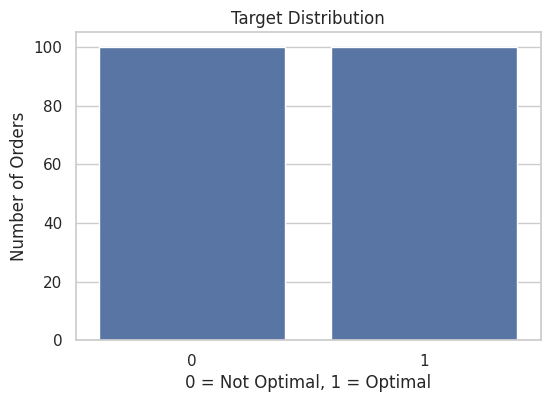

In [53]:
plt.figure(figsize=(6, 4))
sns.countplot(x="optimal_route", data=df)
plt.title("Target Distribution")
plt.xlabel("0 = Not Optimal, 1 = Optimal")
plt.ylabel("Number of Orders")
plt.show()

## Feature and Target Selection

### 8.1 Define Columns to Remove

In [54]:
drop_columns = [
    "order_id",
    "order_time",
    "delivery_time_min",
    "time_per_km",
    "optimal_route",
    "route_score",
    "time_per_km_scaled",
    "delivery_time_scaled",
    "route_inefficiency_score",
    "route_inefficiency_scaled"
]

print("Columns planned to remove:")
print(drop_columns)

Columns planned to remove:
['order_id', 'order_time', 'delivery_time_min', 'time_per_km', 'optimal_route', 'route_score', 'time_per_km_scaled', 'delivery_time_scaled', 'route_inefficiency_score', 'route_inefficiency_scaled']


### 8.2 Filter Existing Drop Columns

In [55]:
existing_drop_columns = [col for col in drop_columns if col in df.columns]

print("Existing columns to remove:")
print(existing_drop_columns)

Existing columns to remove:
['order_id', 'order_time', 'delivery_time_min', 'time_per_km', 'optimal_route', 'route_score', 'time_per_km_scaled', 'delivery_time_scaled', 'route_inefficiency_score', 'route_inefficiency_scaled']


### 8.3 Define Feature Variables

In [56]:
X = df.drop(columns=existing_drop_columns)

print("Feature variables created successfully.")
display(X.head())

Feature variables created successfully.


,distance_km,traffic_level,route_length_km,delivery_mode,weather,restaurant_zone,customer_zone,order_hour,time_category,same_zone,route_efficiency_ratio
0,7.97,High,9.75,Bicycle,Clear,South,North,15,Evening,0,0.817436
1,0.90,High,1.28,Car,Cloudy,West,North,0,Night,0,0.703125
2,11.12,Medium,16.65,Bike,Rainy,South,Central,17,Evening,0,0.667868
3,4.90,Low,5.25,Scooter,Rainy,Central,Central,14,Afternoon,1,0.933333
4,10.04,High,11.34,Car,Rainy,West,North,16,Evening,0,0.885362


### 8.4 Define Target Variable

In [57]:
y = df["optimal_route"]

print("Target variable created successfully.")
display(y.head())

Target variable created successfully.


,optimal_route
0,0
1,0
2,0
3,1
4,1


### 8.5 Check Selected Features

In [58]:
print("Selected features:")
print(X.columns.tolist())

Selected features:
['distance_km', 'traffic_level', 'route_length_km', 'delivery_mode', 'weather', 'restaurant_zone', 'customer_zone', 'order_hour', 'time_category', 'same_zone', 'route_efficiency_ratio']


### 8.6 Check Selected Target

In [59]:
print("Selected target:")
print(y.name)

Selected target:
optimal_route


### 8.7 Check Final Target Distribution

In [60]:
print("Final target distribution:")
display(y.value_counts())

Final target distribution:


,count
optimal_route,
0,100
1,100


## Train Test Splitting

### 9.1 Split Dataset into Training and Testing Data

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

Train-test split completed successfully.


### 9.2 Check Feature Split Shape

In [62]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (160, 11)
X_test shape : (40, 11)


### 9.3 Check Target Split Shape

In [63]:
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

y_train shape: (160,)
y_test shape : (40,)


### 9.4 Check Target Distribution in Training Data

In [64]:
print("Target distribution in training data:")
display(y_train.value_counts(normalize=True) * 100)

Target distribution in training data:


,proportion
optimal_route,
0,50.0
1,50.0


### 9.5 Check Target Distribution in Testing Data

In [65]:
print("Target distribution in testing data:")
display(y_test.value_counts(normalize=True) * 100)

Target distribution in testing data:


,proportion
optimal_route,
0,50.0
1,50.0


## Preprocessing Pipeline

### 10.1 Identify Numerical Features

In [66]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

Numerical features:
['distance_km', 'route_length_km', 'same_zone', 'route_efficiency_ratio']


### 10.2 Identify Categorical Features

In [67]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['traffic_level', 'delivery_mode', 'weather', 'restaurant_zone', 'customer_zone', 'time_category']


### 10.3 Create Preprocessing Pipeline

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Model Evaluation Function

### 11.1 Prepare Model Result Storage

In [69]:
model_results = []

print("Model result storage created successfully.")

Model result storage created successfully.


### 11.2 Define Model Evaluation Function

In [70]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    print("\n" + "=" * 80)
    print(f"MODEL EVALUATION RESULT: {model_name}")
    print("=" * 80)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    return model

## Decision Tree Model

### 12.1 Create Decision Tree Pipeline

In [71]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=3
    ))
])

print("Decision Tree pipeline created successfully.")

Decision Tree pipeline created successfully.


### 12.2 Train and Evaluate Decision Tree


MODEL EVALUATION RESULT: Decision Tree
Accuracy : 0.8
Precision: 0.7308
Recall   : 0.95
F1-Score : 0.8261
ROC-AUC  : 0.8475

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.65      0.76        20
           1       0.73      0.95      0.83        20

    accuracy                           0.80        40
   macro avg       0.83      0.80      0.80        40
weighted avg       0.83      0.80      0.80        40



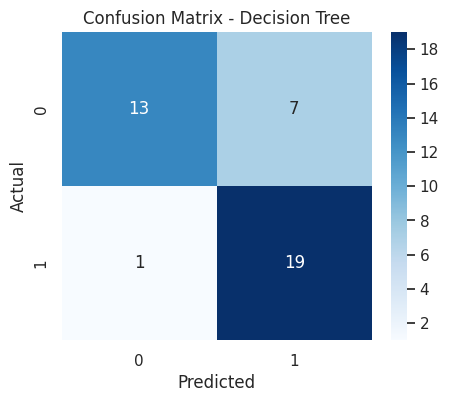

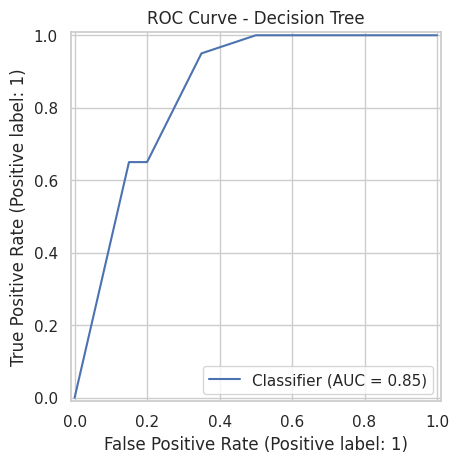

In [72]:
decision_tree_model = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)

## Logistic Regression Model

### 13.1 Create Logistic Regression Pipeline

In [73]:
logistic_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


### 13.2 Train and Evaluate Logistic Regression


MODEL EVALUATION RESULT: Logistic Regression
Accuracy : 0.875
Precision: 0.8
Recall   : 1.0
F1-Score : 0.8889
ROC-AUC  : 0.9525

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86        20
           1       0.80      1.00      0.89        20

    accuracy                           0.88        40
   macro avg       0.90      0.88      0.87        40
weighted avg       0.90      0.88      0.87        40



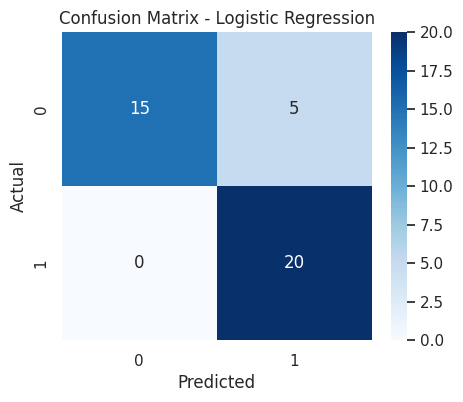

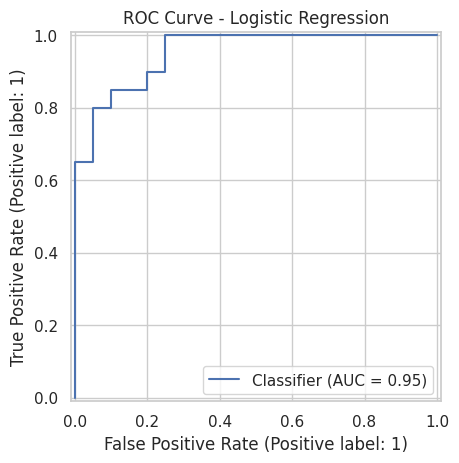

In [74]:
logistic_regression_model = evaluate_model(
    "Logistic Regression",
    logistic_regression_model,
    X_train,
    X_test,
    y_train,
    y_test
)

## k-Nearest Neighbour Model

### 14.1 Create k-NN Pipeline

In [75]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=7
    ))
])

print("k-Nearest Neighbour pipeline created successfully.")

k-Nearest Neighbour pipeline created successfully.


### 14.2 Train and Evaluate k-NN


MODEL EVALUATION RESULT: k-Nearest Neighbour
Accuracy : 0.8
Precision: 0.7727
Recall   : 0.85
F1-Score : 0.8095
ROC-AUC  : 0.8988

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.77      0.85      0.81        20

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



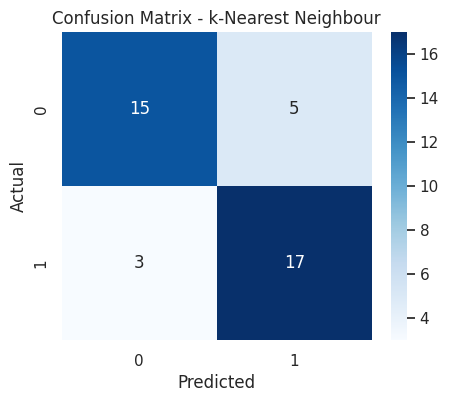

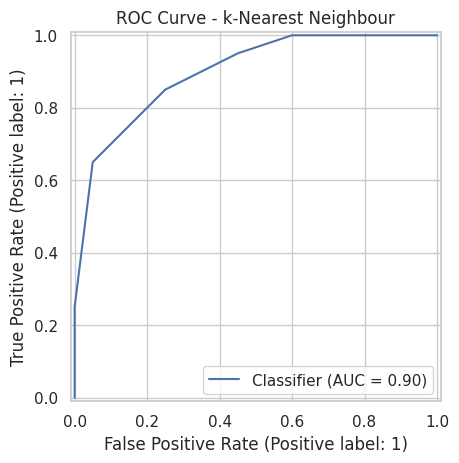

In [76]:
knn_model = evaluate_model(
    "k-Nearest Neighbour",
    knn_model,
    X_train,
    X_test,
    y_train,
    y_test
)

## Initial Model Comparison

### 15.1 Create Initial Model Comparison Table

In [77]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print("Initial model comparison:")
display(results_df)

Initial model comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression,0.875,0.800000,1.00,0.888889,0.95250
2,k-Nearest Neighbour,0.800,0.772727,0.85,0.809524,0.89875
0,Decision Tree,0.800,0.730769,0.95,0.826087,0.84750


### 15.2 Define Metrics for Visualization

In [78]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

print("Metrics to plot:")
print(metrics_to_plot)

Metrics to plot:
['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']


### 15.3 Visualize Accuracy Comparison

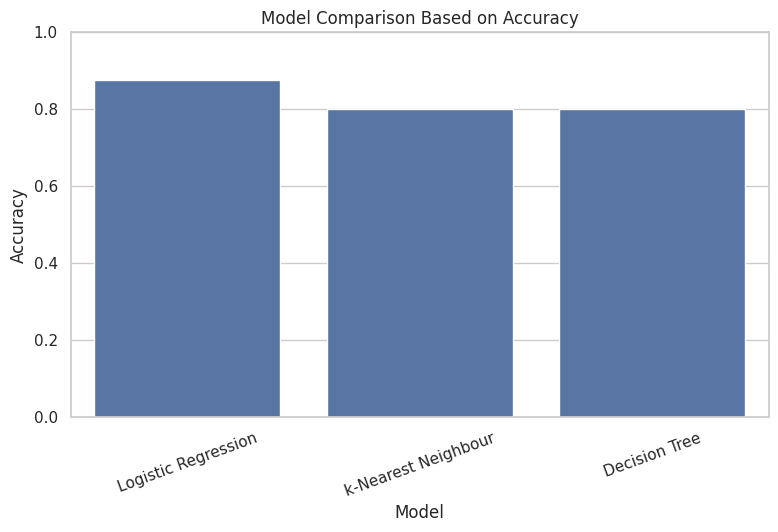

In [79]:
plt.figure(figsize=(9, 5))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Comparison Based on Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### 15.4 Visualize Precision Comparison

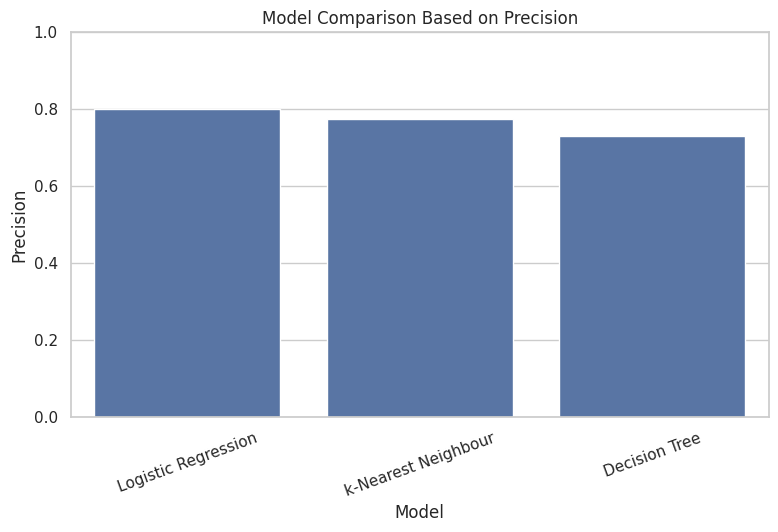

In [80]:
plt.figure(figsize=(9, 5))
sns.barplot(x="Model", y="Precision", data=results_df)
plt.title("Model Comparison Based on Precision")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### 15.5 Visualize Recall Comparison

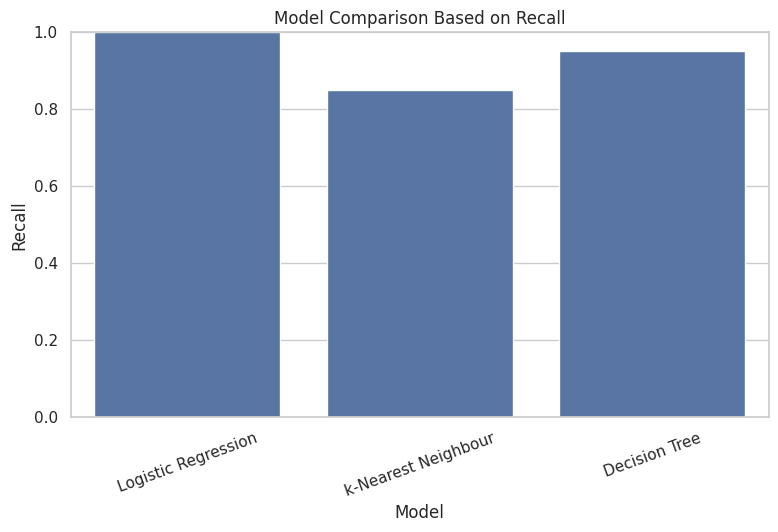

In [81]:
plt.figure(figsize=(9, 5))
sns.barplot(x="Model", y="Recall", data=results_df)
plt.title("Model Comparison Based on Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### 15.6 Visualize F1-Score Comparison

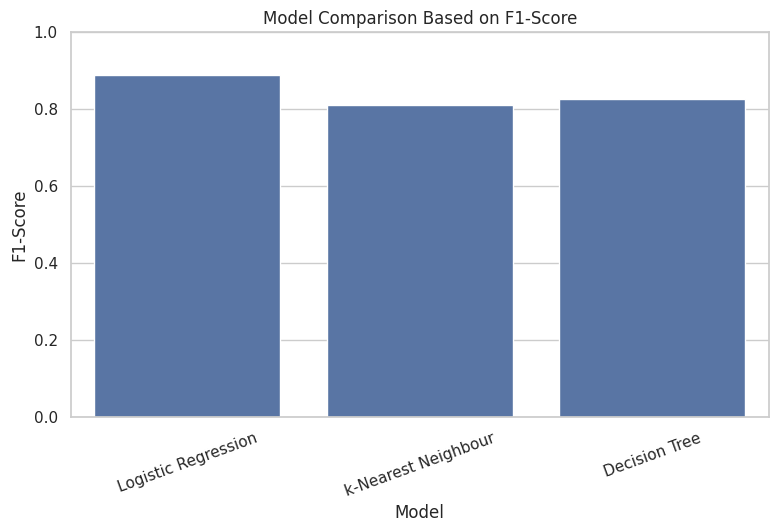

In [82]:
plt.figure(figsize=(9, 5))
sns.barplot(x="Model", y="F1-Score", data=results_df)
plt.title("Model Comparison Based on F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### 15.7 Visualize ROC-AUC Comparison

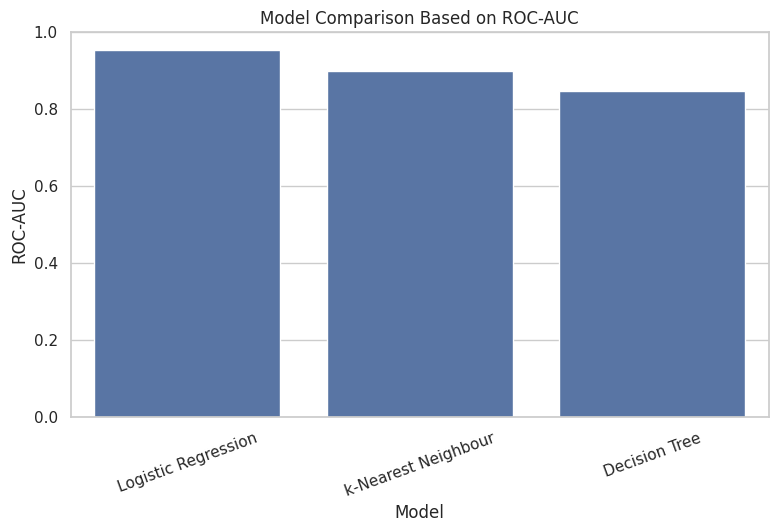

In [83]:
plt.figure(figsize=(9, 5))
sns.barplot(x="Model", y="ROC-AUC", data=results_df)
plt.title("Model Comparison Based on ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## Cross Validation

### 16.1 Prepare Models for Cross Validation

In [84]:
models_for_cv = {
    "Decision Tree": decision_tree_model,
    "Logistic Regression": logistic_regression_model,
    "k-Nearest Neighbour": knn_model
}

print("Models for cross validation prepared successfully.")

Models for cross validation prepared successfully.


### 16.2 Prepare Cross Validation Result Storage

In [85]:
cv_results = []

print("Cross validation result storage created successfully.")

Cross validation result storage created successfully.


### 16.3 Run Cross Validation for All Models

In [86]:
for model_name, model in models_for_cv.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": model_name,
        "CV Accuracy Mean": scores.mean(),
        "CV Accuracy Std": scores.std()
    })

print("Cross validation completed successfully.")

Cross validation completed successfully.


### 16.4 Create Cross Validation Result Table

In [87]:
cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values(by="CV Accuracy Mean", ascending=False)

print("Cross validation results:")
display(cv_df)

Cross validation results:


,Model,CV Accuracy Mean,CV Accuracy Std
1,Logistic Regression,0.780,0.050990
2,k-Nearest Neighbour,0.775,0.074162
0,Decision Tree,0.715,0.080000


## Decision Tree Tuning

### 17.1 Define Decision Tree Hyperparameter Grid

In [88]:
param_grid_dt = {
    "classifier__max_depth": [3, 4, 5, 6, 7, 8, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 3, 4, 5]
}

print("Decision Tree hyperparameter grid created successfully.")

Decision Tree hyperparameter grid created successfully.


### 17.2 Create Decision Tree GridSearchCV

In [89]:
grid_dt = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]),
    param_grid=param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Decision Tree GridSearchCV created successfully.")

Decision Tree GridSearchCV created successfully.


### 17.3 Fit Decision Tree Tuning Model

In [90]:
grid_dt.fit(X_train, y_train)

print("Decision Tree tuning completed successfully.")

Decision Tree tuning completed successfully.


### 17.4 Show Best Decision Tree Parameters

In [91]:
print("Best Decision Tree parameters:")
print(grid_dt.best_params_)

Best Decision Tree parameters:
{'classifier__max_depth': 3, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 10}


### 17.5 Show Best Decision Tree CV Score

In [92]:
print("Best Decision Tree CV score:")
print(grid_dt.best_score_)

Best Decision Tree CV score:
0.7625


### 17.6 Save Best Decision Tree Model

In [93]:
best_decision_tree_model = grid_dt.best_estimator_

print("Best Decision Tree model saved successfully.")

Best Decision Tree model saved successfully.


### 17.7 Evaluate Tuned Decision Tree


MODEL EVALUATION RESULT: Tuned Decision Tree
Accuracy : 0.775
Precision: 0.7391
Recall   : 0.85
F1-Score : 0.7907
ROC-AUC  : 0.8275

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.74      0.85      0.79        20

    accuracy                           0.78        40
   macro avg       0.78      0.77      0.77        40
weighted avg       0.78      0.78      0.77        40



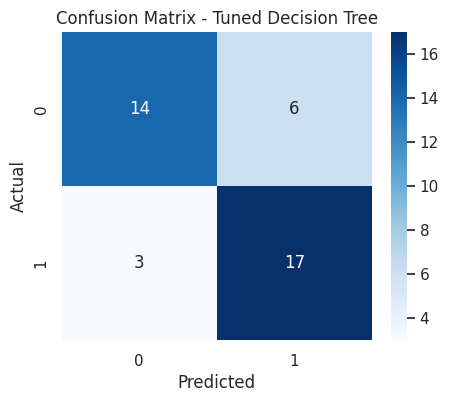

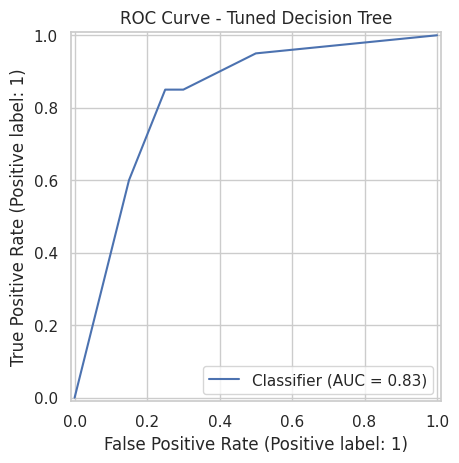

In [94]:
best_decision_tree_model = evaluate_model(
    "Tuned Decision Tree",
    best_decision_tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)

## k-Nearest Neighbour Tuning

### 18.1 Define k-NN Hyperparameter Grid

In [95]:
param_grid_knn = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

print("k-NN hyperparameter grid created successfully.")

k-NN hyperparameter grid created successfully.


### 18.2 Create k-NN GridSearchCV

In [96]:
grid_knn = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]),
    param_grid=param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("k-NN GridSearchCV created successfully.")

k-NN GridSearchCV created successfully.


### 18.3 Fit k-NN Tuning Model

In [97]:
grid_knn.fit(X_train, y_train)

print("k-NN tuning completed successfully.")

k-NN tuning completed successfully.


### 18.4 Show Best k-NN Parameters

In [98]:
print("Best k-NN parameters:")
print(grid_knn.best_params_)

Best k-NN parameters:
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}


### 18.5 Show Best k-NN CV Score

In [99]:
print("Best k-NN CV score:")
print(grid_knn.best_score_)

Best k-NN CV score:
0.81875


### 18.6 Save Best k-NN Model

In [100]:
best_knn_model = grid_knn.best_estimator_

print("Best k-NN model saved successfully.")

Best k-NN model saved successfully.


### 18.7 Evaluate Tuned k-NN


MODEL EVALUATION RESULT: Tuned k-Nearest Neighbour
Accuracy : 0.8
Precision: 0.7727
Recall   : 0.85
F1-Score : 0.8095
ROC-AUC  : 0.8988

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.77      0.85      0.81        20

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



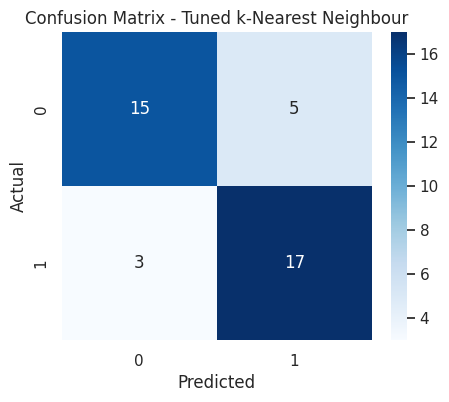

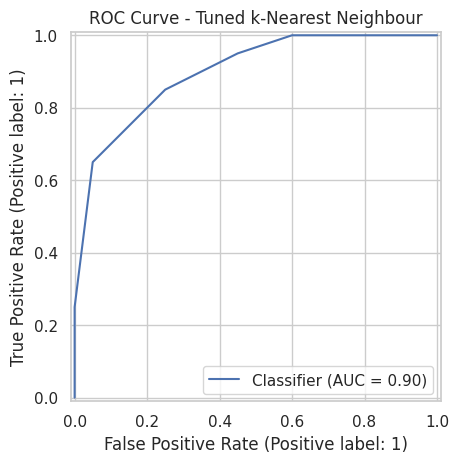

In [101]:
best_knn_model = evaluate_model(
    "Tuned k-Nearest Neighbour",
    best_knn_model,
    X_train,
    X_test,
    y_train,
    y_test
)

## Final Model Result

### 19.1 Create Final Model Result Table

In [102]:
final_results_df = pd.DataFrame(model_results)
final_results_df = final_results_df.sort_values(by="ROC-AUC", ascending=False)

print("Final model results:")
display(final_results_df)

Final model results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression,0.875,0.800000,1.00,0.888889,0.95250
4,Tuned k-Nearest Neighbour,0.800,0.772727,0.85,0.809524,0.89875
2,k-Nearest Neighbour,0.800,0.772727,0.85,0.809524,0.89875
0,Decision Tree,0.800,0.730769,0.95,0.826087,0.84750
3,Tuned Decision Tree,0.775,0.739130,0.85,0.790698,0.82750


### 19.2 Select Best Model Based on ROC-AUC

In [103]:
best_model_row = final_results_df.iloc[0]

print("Best model based on ROC-AUC:")
display(best_model_row)

Best model based on ROC-AUC:


,1
Model,Logistic Regression
Accuracy,0.875
Precision,0.8
Recall,1.0
F1-Score,0.888889
ROC-AUC,0.9525


### 19.3 Show Best Model Name

In [125]:
best_model_name = best_model_row["Model"]

print("Best model name:")
print(best_model_name)

Best model name:
Logistic Regression


## Decision Tree Feature Importance

### 20.1 Extract Fitted Decision Tree Preprocessor

In [105]:
best_dt_preprocessor = best_decision_tree_model.named_steps["preprocessor"]

print("Fitted Decision Tree preprocessor extracted successfully.")

Fitted Decision Tree preprocessor extracted successfully.


### 20.2 Extract Fitted Decision Tree Classifier

In [106]:
best_dt_classifier = best_decision_tree_model.named_steps["classifier"]

print("Fitted Decision Tree classifier extracted successfully.")

Fitted Decision Tree classifier extracted successfully.


### 20.3 Get Encoded Categorical Feature Names

In [107]:
cat_feature_names = best_dt_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

print("Encoded categorical feature names extracted successfully.")
print(cat_feature_names)

Encoded categorical feature names extracted successfully.
['traffic_level_High' 'traffic_level_Low' 'traffic_level_Medium'
 'delivery_mode_Bicycle' 'delivery_mode_Bike' 'delivery_mode_Car'
 'delivery_mode_Scooter' 'weather_Clear' 'weather_Cloudy' 'weather_Rainy'
 'weather_Windy' 'restaurant_zone_Central' 'restaurant_zone_East'
 'restaurant_zone_North' 'restaurant_zone_South' 'restaurant_zone_West'
 'customer_zone_Central' 'customer_zone_East' 'customer_zone_North'
 'customer_zone_South' 'customer_zone_West' 'time_category_Afternoon'
 'time_category_Evening' 'time_category_Morning' 'time_category_Night']


### 20.4 Combine All Feature Names

In [108]:
all_feature_names = numeric_features + list(cat_feature_names)

print("All feature names combined successfully.")
print(all_feature_names)

All feature names combined successfully.
['distance_km', 'route_length_km', 'same_zone', 'route_efficiency_ratio', 'traffic_level_High', 'traffic_level_Low', 'traffic_level_Medium', 'delivery_mode_Bicycle', 'delivery_mode_Bike', 'delivery_mode_Car', 'delivery_mode_Scooter', 'weather_Clear', 'weather_Cloudy', 'weather_Rainy', 'weather_Windy', 'restaurant_zone_Central', 'restaurant_zone_East', 'restaurant_zone_North', 'restaurant_zone_South', 'restaurant_zone_West', 'customer_zone_Central', 'customer_zone_East', 'customer_zone_North', 'customer_zone_South', 'customer_zone_West', 'time_category_Afternoon', 'time_category_Evening', 'time_category_Morning', 'time_category_Night']


### 20.5 Create Feature Importance Table

In [109]:
feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": best_dt_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print("Decision Tree feature importance:")
display(feature_importance.head(15))

Decision Tree feature importance:


,Feature,Importance
1,route_length_km,0.469422
3,route_efficiency_ratio,0.403984
0,distance_km,0.080312
21,customer_zone_East,0.046283
2,same_zone,0.000000
5,traffic_level_Low,0.000000
6,traffic_level_Medium,0.000000
7,delivery_mode_Bicycle,0.000000
8,delivery_mode_Bike,0.000000
9,delivery_mode_Car,0.000000


### 20.6 Visualize Feature Importance

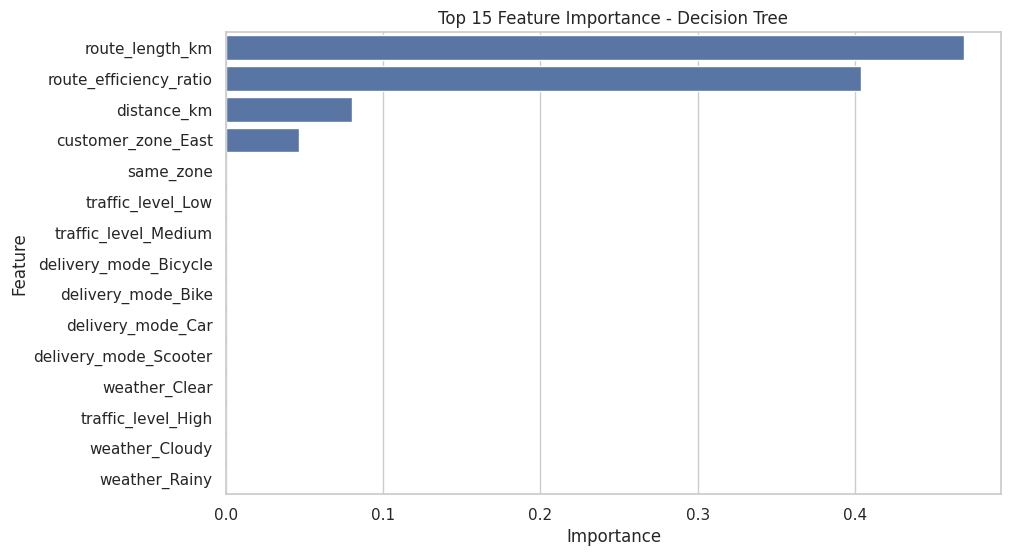

In [110]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)
plt.title("Top 15 Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Decision Tree Visualization

### 21.1 Visualize Tuned Decision Tree

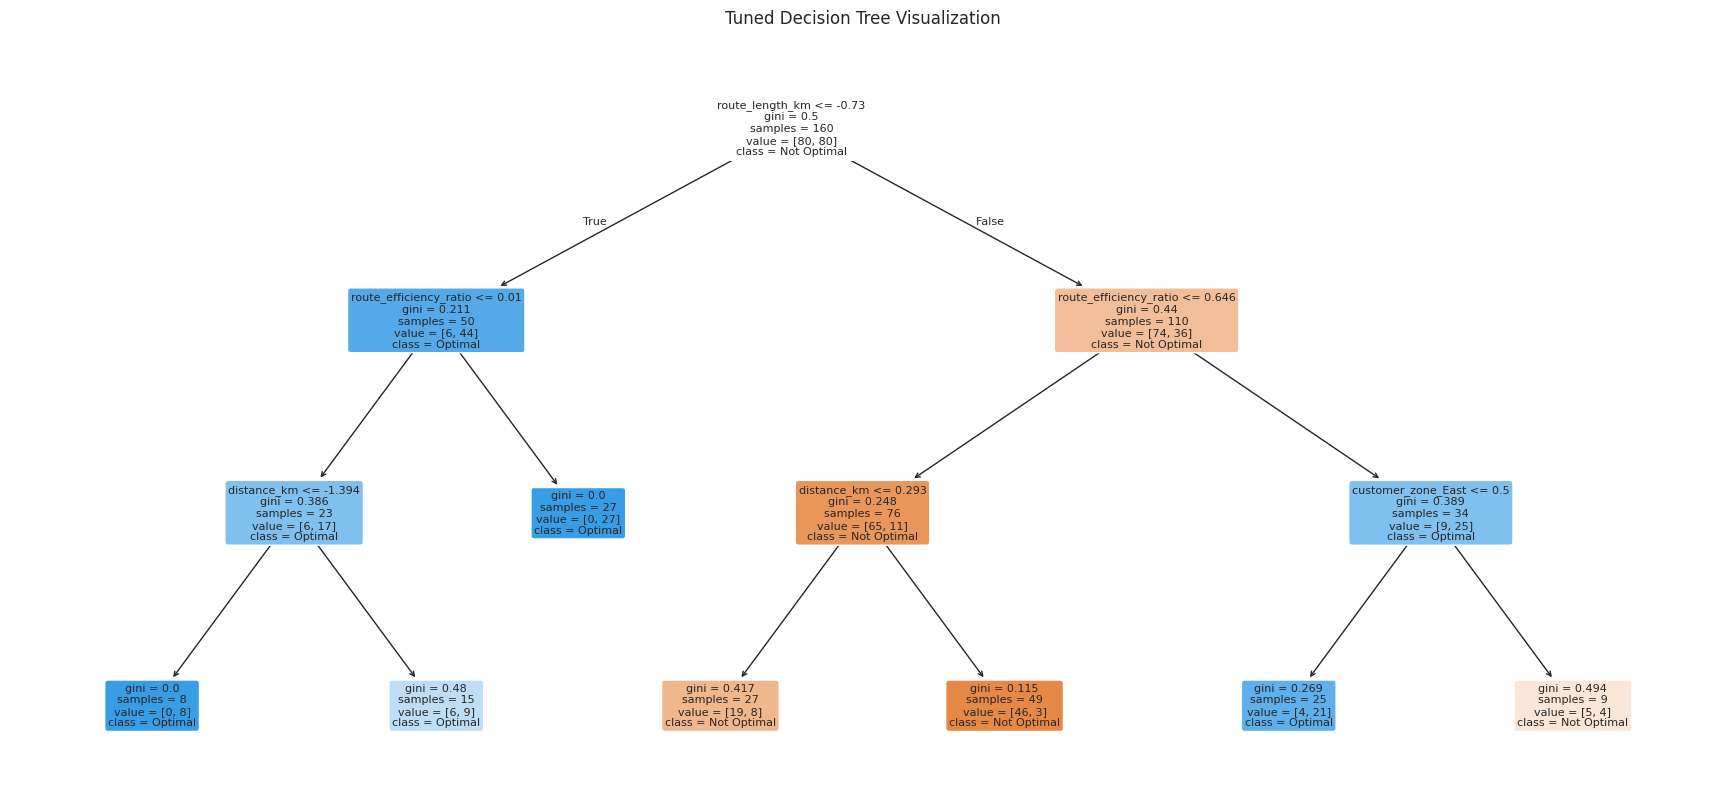

In [111]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt_classifier,
    feature_names=all_feature_names,
    class_names=["Not Optimal", "Optimal"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Tuned Decision Tree Visualization")
plt.show()

## New Order Prediction

### 22.1 Create New Order Data

In [121]:
new_order = pd.DataFrame({
    "distance_km": [5.5],
    "traffic_level": ["Medium"],
    "route_length_km": [6.2],
    "delivery_mode": ["Bike"],
    "weather": ["Clear"],
    "restaurant_zone": ["Central"],
    "customer_zone": ["North"],
    "order_hour": [12],
    "time_category": ["Afternoon"],
    "same_zone": [0],
    "route_efficiency_ratio": [5.5 / 6.2]
})

print("New order data created successfully.")
display(new_order)

New order data created successfully.


,distance_km,traffic_level,route_length_km,delivery_mode,weather,restaurant_zone,customer_zone,order_hour,time_category,same_zone,route_efficiency_ratio
0,5.5,Medium,6.2,Bike,Clear,Central,North,12,Afternoon,0,0.887097


### 22.2 Predict New Order Class

In [122]:
prediction = best_decision_tree_model.predict(new_order)[0]

print("Predicted optimal_route:")
print(prediction)

Predicted optimal_route:
1


### 22.3 Predict New Order Probability

In [123]:
prediction_probability = best_decision_tree_model.predict_proba(new_order)[0][1]

print("Probability of optimal route:")
print(round(prediction_probability, 4))

Probability of optimal route:
0.84


### 22.4 Interpret New Order Prediction

In [124]:
if prediction == 1:
    print("Interpretation: The route is predicted as OPTIMAL.")
else:
    print("Interpretation: The route is predicted as NOT OPTIMAL.")

Interpretation: The route is predicted as OPTIMAL.
